# Burned Area Center-Padding Audit

This notebook audits the `burned_area` tiles after the center-padding fix.

For representative `train` and `validation` samples it shows:

- the raw routerset source patch
- the old top-left materialized tile
- the corrected centered materialized tile
- the old nonzero mask
- the new nonzero mask

The goal is to verify that the large black slab came from padding placement,
not from black source pixels.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

OLD_ROOT = PROJECT_ROOT / 'outputs' / 'routerset' / 'fix30March_floatminmax_selected_anomalyfix'
NEW_ROOT = PROJECT_ROOT / 'outputs' / 'routerset' / 'fix31March_floatminmax_centerpad_firefix_selected'
MANIFEST_PATH = NEW_ROOT / 'manifest_256.jsonl'
AUDIT_PATH = PROJECT_ROOT / 'outputs' / 'routerset' / 'burned_area_centerpad_audit.json'

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
set_matplotlib_formats('png')
plt.rcParams['figure.figsize'] = (18, 4)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.max_open_warning'] = 0

print('project_root:', PROJECT_ROOT)
print('old_root:', OLD_ROOT)
print('new_root:', NEW_ROOT)
print('manifest_exists:', MANIFEST_PATH.exists())
print('audit_exists:', AUDIT_PATH.exists())


project_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2
old_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix30March_floatminmax_selected_anomalyfix
new_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix31March_floatminmax_centerpad_firefix_selected
manifest_exists: True
audit_exists: True


In [2]:
def load_manifest_rows(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]


rows = [
    row
    for row in load_manifest_rows(MANIFEST_PATH)
    if row['source_dataset'] == 'burned_area'
]
rows = sorted(rows, key=lambda row: (row.get('moe_split', row['source_split']), str(row['source_sample_id']), str(row['materialized_image_path'])))

train_rows = [row for row in rows if row.get('moe_split', row['source_split']) == 'train']
validation_rows = [row for row in rows if row.get('moe_split', row['source_split']) == 'validation']

selected_rows = [
    train_rows[0],
    train_rows[len(train_rows) // 2],
    validation_rows[0],
    validation_rows[len(validation_rows) // 2],
]

display(Markdown('## Selected rows'))
for row in selected_rows:
    print(json.dumps(
        {
            'split': row.get('moe_split', row['source_split']),
            'sample_id': row['source_sample_id'],
            'materialized_from': row['materialized_from'],
            'materialized_image_path': row['materialized_image_path'],
            'labels': row.get('label_names') or [],
        },
        indent=2,
    ))


## Selected rows

{
  "split": "train",
  "sample_id": "0000002",
  "materialized_from": "routerset/multilabel_dataset/images/burned_area/train/0000002_0_0_64_128.npy",
  "materialized_image_path": "outputs/routerset/fix31March_floatminmax_centerpad_firefix_selected/images/burned_area/train/0000002_0_0_256_256.npy",
  "labels": []
}
{
  "split": "train",
  "sample_id": "0004110",
  "materialized_from": "routerset/multilabel_dataset/images/burned_area/train/0004110_192_0_64_128.npy",
  "materialized_image_path": "outputs/routerset/fix31March_floatminmax_centerpad_firefix_selected/images/burned_area/train/0004110_0_192_256_256.npy",
  "labels": [
    "cloud"
  ]
}
{
  "split": "validation",
  "sample_id": "0000075",
  "materialized_from": "routerset/multilabel_dataset/images/burned_area/validation/0000075_192_0_64_128.npy",
  "materialized_image_path": "outputs/routerset/fix31March_floatminmax_centerpad_firefix_selected/images/burned_area/validation/0000075_0_192_256_256.npy",
  "labels": []
}
{
  "split"

In [3]:
FALSE_RGB_CHANNELS = (4, 2, 1)


def resolve_path(value: str | Path) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def normalize_display(chw: np.ndarray, channels: tuple[int, int, int] = FALSE_RGB_CHANNELS) -> np.ndarray:
    safe_channels = tuple(min(index, chw.shape[0] - 1) for index in channels)
    rgb = np.stack([chw[index] for index in safe_channels], axis=-1).astype(np.float32)
    lo = np.percentile(rgb, 2.0)
    hi = np.percentile(rgb, 98.0)
    if hi <= lo:
        return np.clip(rgb, 0.0, 1.0)
    rgb = (rgb - lo) / (hi - lo)
    return np.clip(rgb, 0.0, 1.0)


def nonzero_bbox(chw: np.ndarray) -> tuple[int, int, int, int]:
    mask = np.any(chw != 0, axis=0)
    ys, xs = np.where(mask)
    return (int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1)


def zero_fraction(chw: np.ndarray) -> float:
    return float((chw == 0).mean())


def load_triplet(row: dict) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    raw = np.load(resolve_path(row['materialized_from']))
    new = np.load(resolve_path(row['materialized_image_path']))
    rel = Path(row['materialized_image_path']).relative_to('outputs/routerset/fix31March_floatminmax_centerpad_firefix_selected')
    old = np.load(OLD_ROOT / rel)
    return raw, old, new


## Visual comparison

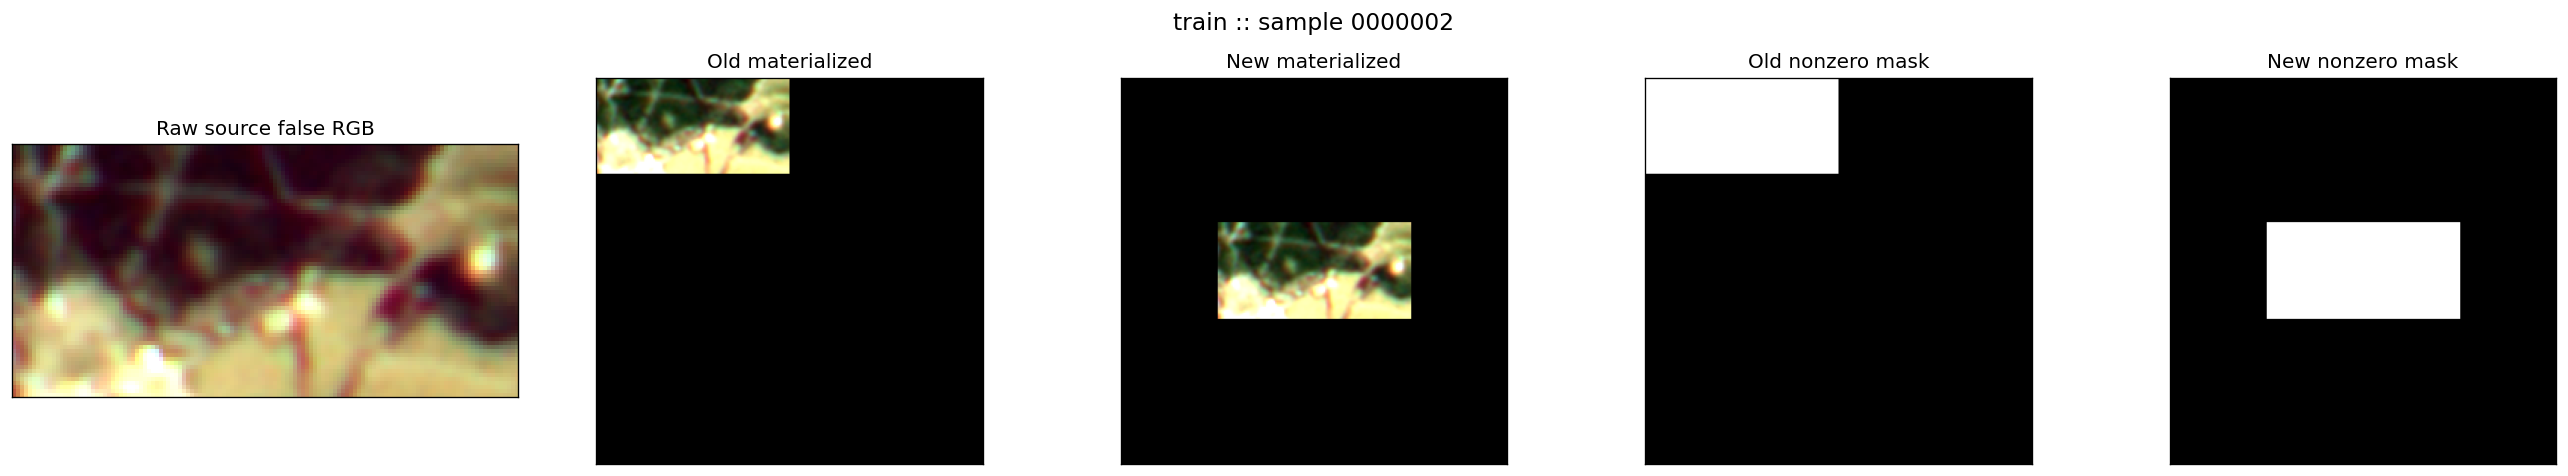

{
  "split": "train",
  "sample_id": "0000002",
  "raw_shape": [
    7,
    64,
    128
  ],
  "raw_zero_fraction": 0.0,
  "old_bbox": [
    0,
    64,
    0,
    128
  ],
  "new_bbox": [
    96,
    160,
    64,
    192
  ],
  "old_zero_fraction": 0.8906383514404297,
  "new_zero_fraction": 0.8906383514404297
}


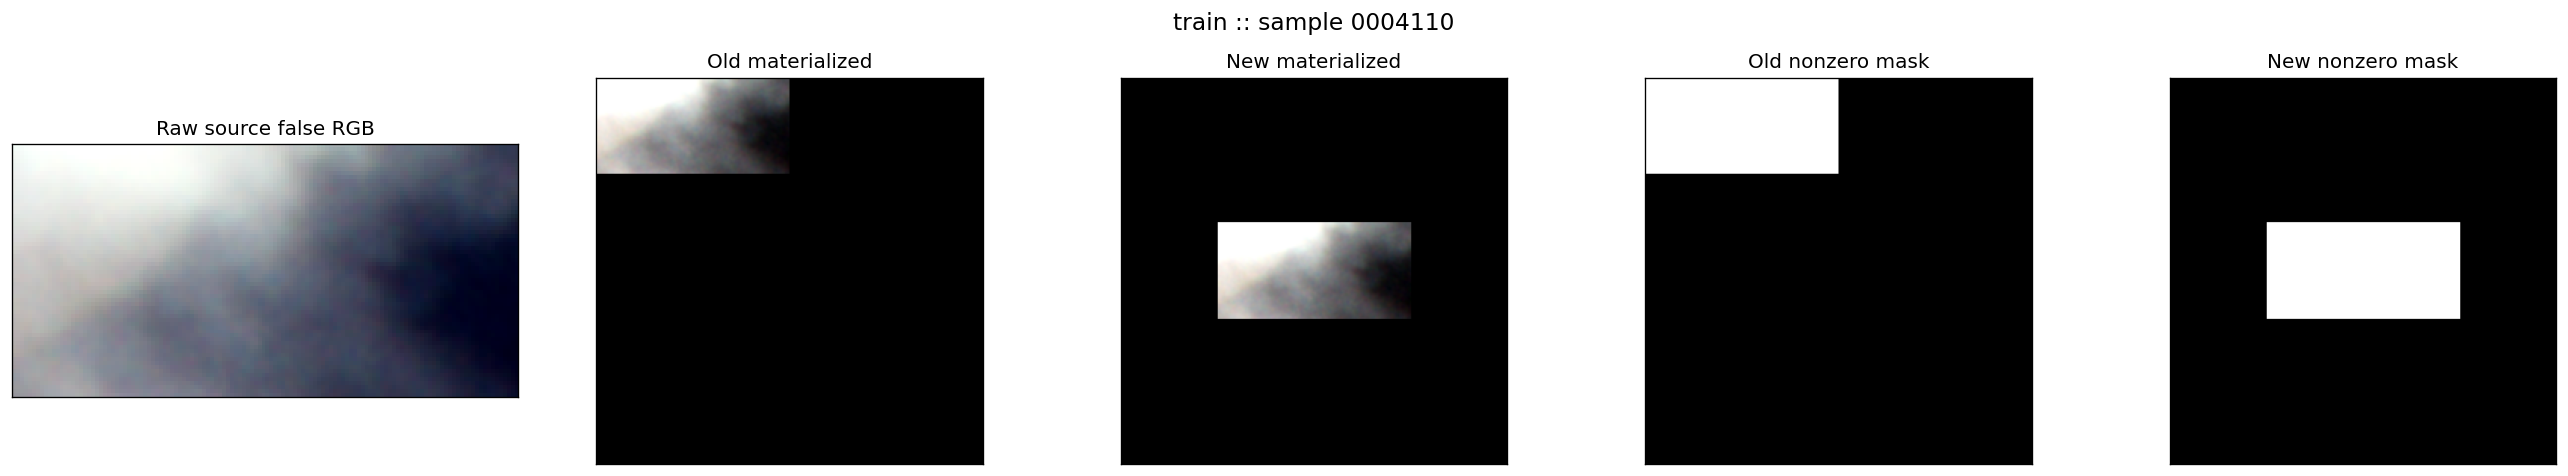

{
  "split": "train",
  "sample_id": "0004110",
  "raw_shape": [
    7,
    64,
    128
  ],
  "raw_zero_fraction": 0.0,
  "old_bbox": [
    0,
    64,
    0,
    128
  ],
  "new_bbox": [
    96,
    160,
    64,
    192
  ],
  "old_zero_fraction": 0.8906383514404297,
  "new_zero_fraction": 0.8906383514404297
}


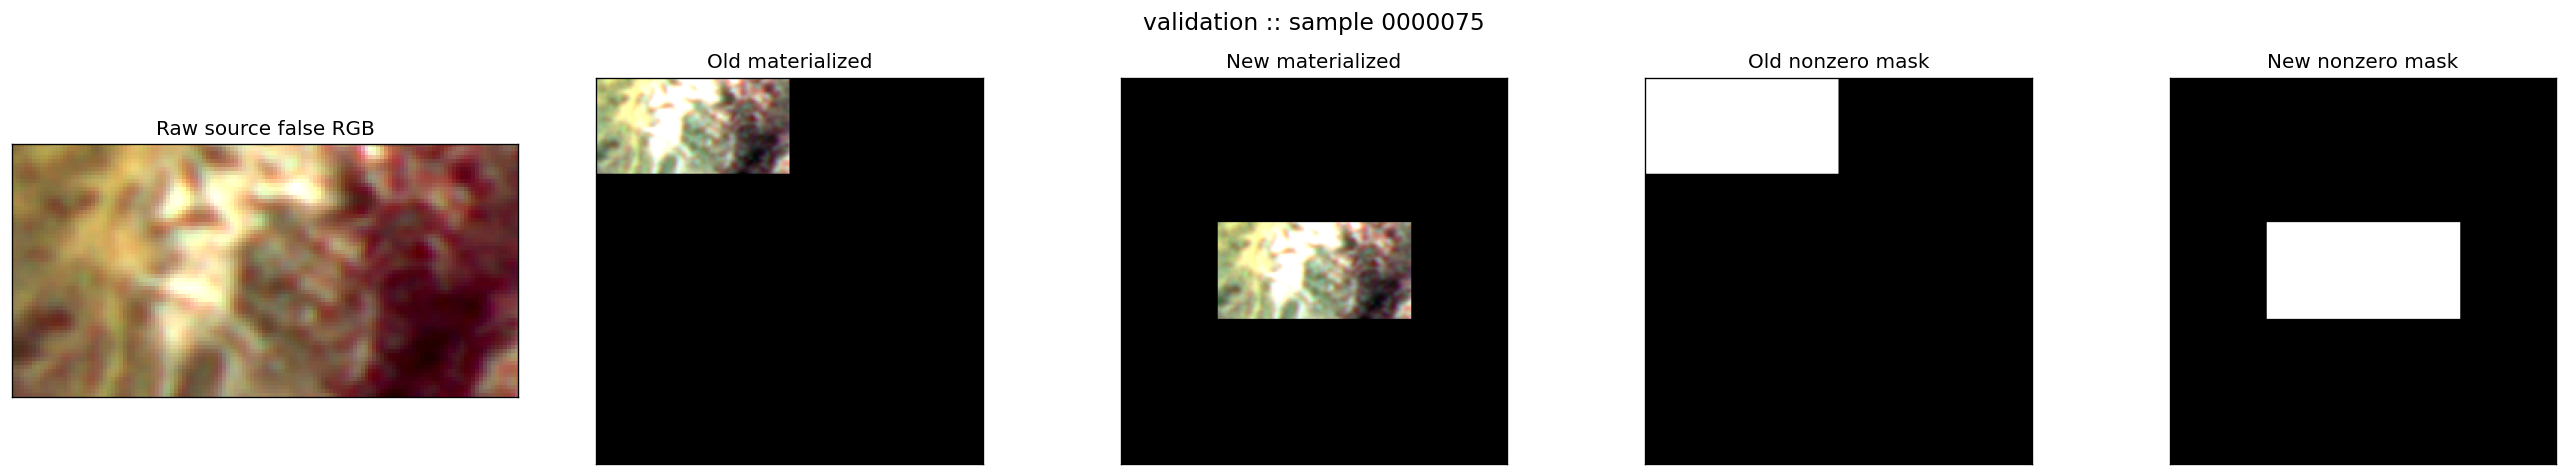

{
  "split": "validation",
  "sample_id": "0000075",
  "raw_shape": [
    7,
    64,
    128
  ],
  "raw_zero_fraction": 0.0,
  "old_bbox": [
    0,
    64,
    0,
    128
  ],
  "new_bbox": [
    96,
    160,
    64,
    192
  ],
  "old_zero_fraction": 0.8906383514404297,
  "new_zero_fraction": 0.8906383514404297
}


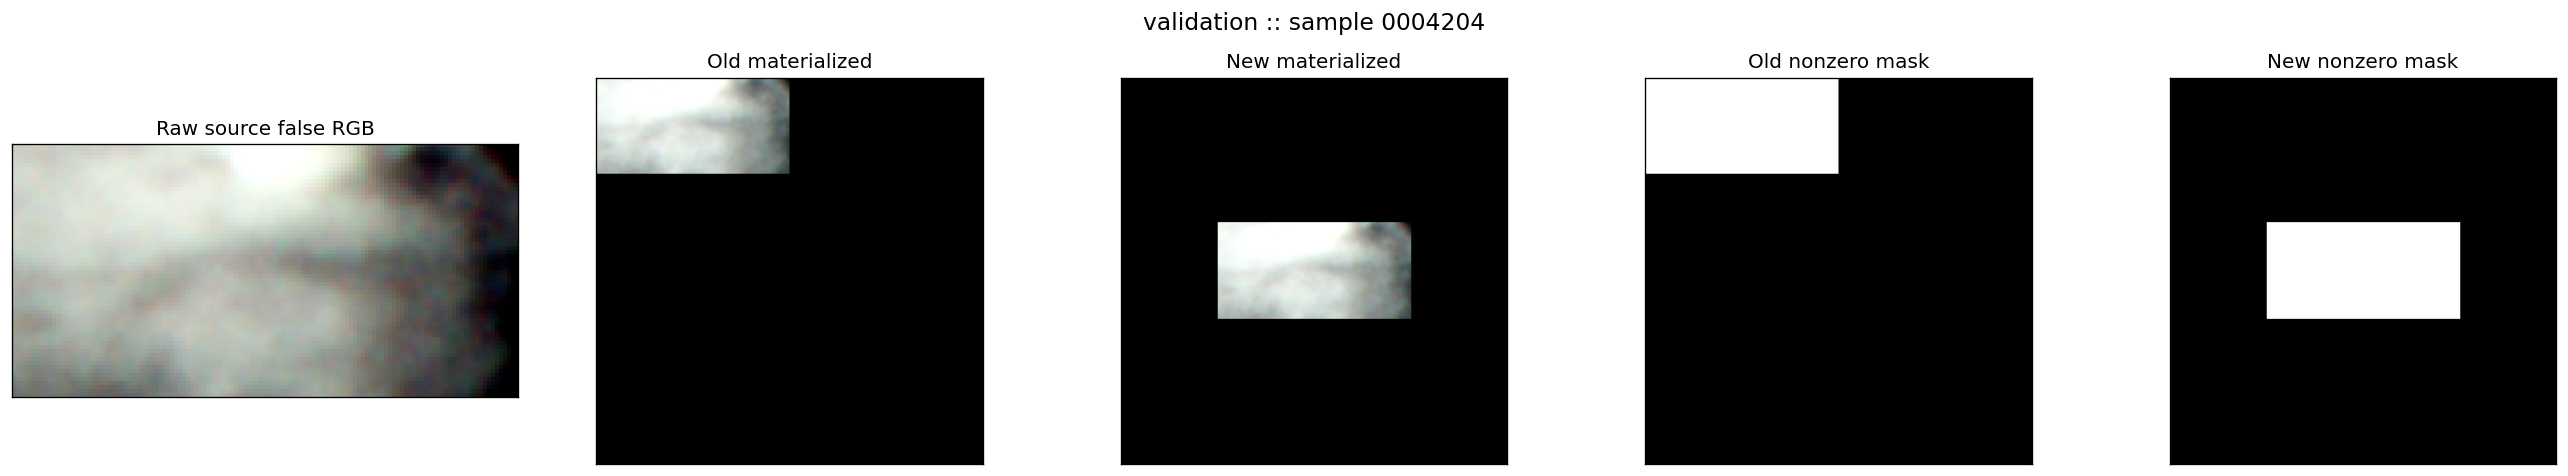

{
  "split": "validation",
  "sample_id": "0004204",
  "raw_shape": [
    7,
    64,
    128
  ],
  "raw_zero_fraction": 0.0,
  "old_bbox": [
    0,
    64,
    0,
    128
  ],
  "new_bbox": [
    96,
    160,
    64,
    192
  ],
  "old_zero_fraction": 0.8906383514404297,
  "new_zero_fraction": 0.8906383514404297
}


In [4]:
display(Markdown('## Visual comparison'))

for row in selected_rows:
    raw, old, new = load_triplet(row)
    old_mask = np.any(old != 0, axis=0).astype(np.float32)
    new_mask = np.any(new != 0, axis=0).astype(np.float32)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    axes[0].imshow(normalize_display(raw))
    axes[0].set_title('Raw source false RGB')
    axes[1].imshow(normalize_display(old))
    axes[1].set_title('Old materialized')
    axes[2].imshow(normalize_display(new))
    axes[2].set_title('New materialized')
    axes[3].imshow(old_mask, cmap='gray', vmin=0.0, vmax=1.0)
    axes[3].set_title('Old nonzero mask')
    axes[4].imshow(new_mask, cmap='gray', vmin=0.0, vmax=1.0)
    axes[4].set_title('New nonzero mask')
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    split = row.get('moe_split', row['source_split'])
    fig.suptitle(f"{split} :: sample {row['source_sample_id']}", fontsize=14)
    plt.tight_layout()
    plt.show()

    summary = {
        'split': split,
        'sample_id': row['source_sample_id'],
        'raw_shape': list(raw.shape),
        'raw_zero_fraction': zero_fraction(raw),
        'old_bbox': nonzero_bbox(old),
        'new_bbox': nonzero_bbox(new),
        'old_zero_fraction': zero_fraction(old),
        'new_zero_fraction': zero_fraction(new),
    }
    print(json.dumps(summary, indent=2))


In [5]:
if AUDIT_PATH.exists():
    display(Markdown('## Audit summary'))
    audit = json.loads(AUDIT_PATH.read_text(encoding='utf-8'))
    print(json.dumps(audit, indent=2))
else:
    print('audit summary not found:', AUDIT_PATH)


## Audit summary

{
  "raw_example": {
    "path": "routerset/multilabel_dataset/images/burned_area/train/0000002_0_0_64_128.npy",
    "shape": [
      7,
      64,
      128
    ],
    "dtype": "float32",
    "zero_fraction": 0.0
  },
  "old_example": {
    "path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/burned_area/train/0000002_0_0_256_256.npy",
    "bbox": [
      0,
      64,
      0,
      128
    ],
    "zero_fraction": 0.8906383514404297
  },
  "new_example": {
    "path": "outputs/routerset/fix31March_floatminmax_centerpad_firefix_selected/images/burned_area/train/0000002_0_0_256_256.npy",
    "bbox": [
      96,
      160,
      64,
      192
    ],
    "zero_fraction": 0.8906383514404297
  },
  "comparison_sample_size": 200,
  "old_unique_bboxes": [
    [
      0,
      64,
      0,
      128
    ]
  ],
  "new_unique_bboxes": [
    [
      96,
      160,
      64,
      192
    ]
  ],
  "old_unique_zero_fractions": [
    0.890638
  ],
  "new_unique_zero_fractions"